Author: @Bahae-Eddine Madir

# (hp) VPINNs

In [1]:
import sys
import os
sys.path.insert(1, './Utilities/')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
from matplotlib.patches import Rectangle

In [4]:
case = 'Galerkin'
savedir = './outputs_' + case + '/'
os.makedirs(savedir, exist_ok=True)
save = True

In [5]:
# A (simple) feed forward N.N.
torch.manual_seed(1234)
class ff(torch.nn.Module):
    def __init__(self, n_neurones):
        super().__init__()
        self.l1 = torch.nn.Linear(2, n_neurones)
        self.act = torch.nn.Tanh()
        self.l2 = torch.nn.Linear(n_neurones, 1)
        self.params_dict = dict(self.named_parameters())
    def forward(self, *inputs):
        inputs = torch.cat(inputs, 1)
        outputs = self.act(self.l1(inputs))
        return self.l2(outputs)

device = torch.device("cpu")
net = ff(15).to(device)

In [6]:
model = net
# if strong BC
#model = lambda x, y: x* (x-1)* y* (y-1)* net(x, y)

In [7]:
# Manufactured Solution
u_ref = lambda x, y: torch.sin(torch.pi* x)* torch.sin(torch.pi* y) + (1/2)* torch.sin(3* torch.pi* x)* torch.sin(2* torch.pi* y)
f = lambda x, y: torch.pi**2* (2* torch.sin(torch.pi* x) + 13* torch.sin(3* torch.pi* x)* torch.cos(torch.pi* y))* torch.sin(torch.pi* y)

## Test fns

In [8]:
def legendre(x, n):
    """
    Compute Legendre polynomials up to degree n at points x.
    Args
        x: Tensor of shape (N,)
    Returns 
        Tensor of shape (n+1, N)
    """

    x = torch.where(x<-1, -1., torch.where(x>1., 1., x))
    P = [torch.ones_like(x), x]
    for k in range(1, n):
        Pk = ((2*k+1)*x*P[-1] - k*P[-2]) / (k+1)
        P.append(Pk)
    return torch.stack(P[:n+1])

In [9]:
def test_fn_1D(x, n):
    l = legendre(x, n)
    return l[2:] - l[:-2]

from torch.func import vmap
tensor_prod = vmap(lambda a, M: a* M, in_dims=(0, None))
def test_fn_2D(x, y, n):
    lx = legendre(x, n)
    phi = lx[2:] - lx[:-2]
    ly = legendre(y, n)
    psi = ly[2:] - ly[:-2]
    return tensor_prod(phi, psi)

## Elements

In [10]:
# Construct the elements
def elements_fn(x, y):
    nx = len(x)
    ny = len(y)
    elements = []
    
    for i in range(nx):
        if x[i:i+2].numel()<2:
            continue
        for j in range(ny):
            if y[j:j+2].numel()<2:
                continue
            else:
                element = [x[i:i+2], y[j:j+2]]
                elements.append(element)

    return elements

In [11]:
nx = 4
ny = 4
x = torch.linspace(0, 1, nx+1).to(device)
y = torch.linspace(0, 1, ny+1).to(device)
elements = elements_fn(x, y)

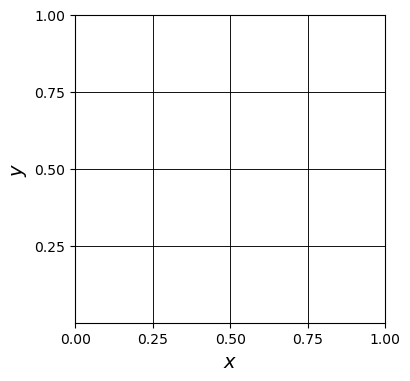

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for e in elements:
    mi_x, mi_y = min(e[0].cpu()), min(e[1].cpu())
    ma_x, ma_y = max(e[0].cpu()), max(e[1].cpu())
    ax.add_patch(Rectangle((mi_x, mi_y), ma_x-mi_x, ma_y-mi_y, fill=False, lw=.5))


ax.set_xticks([0, 0.25, 0.5, .75, 1])
ax.set_yticks([0.25, 0.5, .75, 1])

#ax.set_title(r'$\{K\}$', pad=10, fontsize=12)
ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

if save:
    plt.savefig(savedir + 'elemnts.pdf', bbox_inches ='tight')
    
plt.show()

## Intergration

In [13]:
# from I_hat to I:
def scale_1D(x, I):
    A = (I[-1] - I[0])/2
    B = (I[-1] + I[0])/2
    return A * x + B, A

# from I to I_hat:
def inv_scale_1D(x):
    A = (x[-1] - x[0])/2
    B = (x[-1] + x[0])/2
    return (x - B)/A
    
# from K_hat to K
def scale(x, y, K):
    x, Jx = scale_1D(x, K[0])
    y, Jy = scale_1D(y, K[1])
    return x, y, Jx, Jy

In [14]:
# Quadrature:
from quadrature import GaussLegendre

q_ord = 10
(x_q, y_q), w_q = GaussLegendre().Quad2d(q_ord)

x_q = torch.Tensor(x_q).flatten()
y_q = torch.Tensor(y_q).flatten()
w_q = torch.Tensor(w_q)

In [15]:
from AutoDiff import AG_grad

In [16]:
n_test_fn = 5
x_q.requires_grad_()
y_q.requires_grad_()
test_fn = test_fn_2D(x_q, y_q, n_test_fn).flatten(end_dim=1)
grad_test_fn = torch.stack(
    list(torch.stack(AG_grad(test_fn[i], (x_q, y_q))) for i in range(len(test_fn)))
).detach()

x_q = x_q.detach()
y_q = y_q.detach()
test_fn = test_fn.detach()

In [17]:
test_fn = test_fn.to(device)
grad_test_fn = grad_test_fn.to(device)

print(len(test_fn))

16


In [18]:
quad = w_q.to(device), x_q.reshape(-1, 1).to(device), y_q.reshape(-1, 1).to(device)

In [19]:
def int_K(K, quad, test_fn, grad_test_fn, f=lambda *args: torch.zeros_like(args[0])):
    """
    the test_fn are computed in K_hat. If test_fn.shape is (n, m) then grad_test_fn.shape is (n, 2, m)
    """
    # quadrature weights and nodes
    w, x, y = quad
    qx, qy = w.shape # order

    # num test_fn
    n_test_fn = len(test_fn)
    
    # scale x, y to K, and compute the Jacobien and rescale the gradient
    x, y, Jx, Jy = scale(x, y, K)
    J = Jx* Jy
    _grad_scale = torch.tensor([[1./Jx], [1./Jy]]).to(device)
    _grad_test_fn = _grad_scale* grad_test_fn
    
    # compute grad_u = (u_x, u_y)
    if not x.requires_grad:
        x.requires_grad_()
    if not y.requires_grad:
        y.requires_grad_()
    u = model(x, y)
    grad_u = torch.stack(AG_grad(u, (x, y))).reshape(2, -1)


    A = torch.einsum("ij, nij->nj", grad_u, _grad_test_fn)
    B = f(x, y).reshape(1, -1) * test_fn
    _integrand = (A - B).reshape(-1, qx, qy)

    _integral = torch.einsum('ji, nij->n', w, J* _integrand)
    _integral = (_integral**2).mean()
    
    return _integral

## Losses

In [20]:
def res_loss():
    loss = 0.
    for K in elements:
        _int = int_K(K, quad, test_fn, grad_test_fn, f) 
        loss += _int
    return loss

In [21]:
def bdry_loss():
    u = model(x_bdry, y_bdry)
    return (u**2).mean()

In [22]:
def err_l2(ref, pred):
    return np.linalg.norm(ref - pred, 2) / np.linalg.norm(ref, 2)

## Data

In [23]:
xl, xu = 0., 1.
yl, yu = 0., 1.
zeros = lambda *args: np.zeros_like(args[0])

In [24]:
from sampling import Sampler, Join_samplers

In [25]:
### Boundary
n_bdry = 51* 4

bc1_sampler = Sampler([xl, yl], [xl, yu], zeros) # at xl
bc2_sampler = Sampler([xu, yl], [xu, yu], zeros) # at xu
bc3_sampler = Sampler([xl, yl], [xu, yl], zeros) # at yl
bc4_sampler = Sampler([xl, yu], [xu, yu], zeros) # at yu
bcs_sampler = Join_samplers([bc1_sampler, bc2_sampler, bc3_sampler, bc4_sampler])

x_bdry, y_bdry, _ = bcs_sampler.sample(n_bdry, device=device)

## Optimization

In [26]:
w_b = 1.

In [27]:
losses = {'data':[], 'physics':[], 'total':[], 'l2':[]}

def closure():
    global l_data, l_phys
    optim.zero_grad()
    
    l_data = bdry_loss()
    l_phys = res_loss()
    loss = w_b* l_data + l_phys
    
    loss.backward()
    
    return loss

In [28]:
optim = torch.optim.LBFGS(
    net.parameters(), 
    line_search_fn="strong_wolfe"
)
n_epochs = 151

In [29]:
nx = 100
x = torch.linspace(0, 1, nx).to(device)
x, y = torch.meshgrid(x, x, indexing="xy")
pred = model(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(nx, nx).cpu()
x = x.cpu()
y = y.cpu()

ref = u_ref(x, y)

In [30]:
%%time

for _ in tqdm(range(n_epochs)) :
    
    loss = optim.step(closure)
    
    # save
    losses['data'].append(l_data.item())
    losses['physics'].append(l_phys.item())
    losses['total'].append(loss.item())

    pred = model(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(nx, nx).cpu()
    losses['l2'].append(err_l2(ref, pred))

  0%|          | 0/151 [00:00<?, ?it/s]

CPU times: user 10min 4s, sys: 585 ms, total: 10min 5s
Wall time: 1min 4s


In [31]:
print(f'Rel. L2 error : {err_l2(ref, pred) :.3e}')

Rel. L2 error : 1.028e-03


## Pred

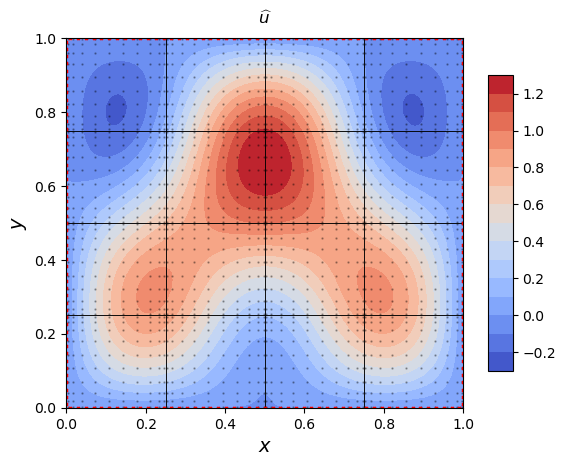

In [32]:
# pred + scatter 

fig, ax = plt.subplots(1, 1)

cb = ax.contourf(x, y, pred, cmap='coolwarm', levels=15)
fig.colorbar(cb, shrink=.8, aspect=12)

for e in elements:
    mi_x, mi_y = min(e[0].cpu()), min(e[1].cpu())
    ma_x, ma_y = max(e[0].cpu()), max(e[1].cpu())
    ax.add_patch(Rectangle((mi_x, mi_y), ma_x-mi_x, ma_y-mi_y, fill=False, lw=.5))
    _x_res, _y_res, _, _ = scale(x_q.to(device), y_q.to(device), e)
    plt.scatter(_x_res.cpu(), _y_res.cpu(), s=.5, alpha=.3, c='k', label='$(x_r, y_r)$')

plt.scatter(x_bdry, y_bdry, c='r', marker='x', s=4)
ax.set_title(r'$\widehat{u}$', pad=10, fontsize=12)
ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

#plt.legend(loc='upper right')

if save:
    plt.savefig(savedir + 'pred.pdf', bbox_inches ='tight')
    
plt.show()

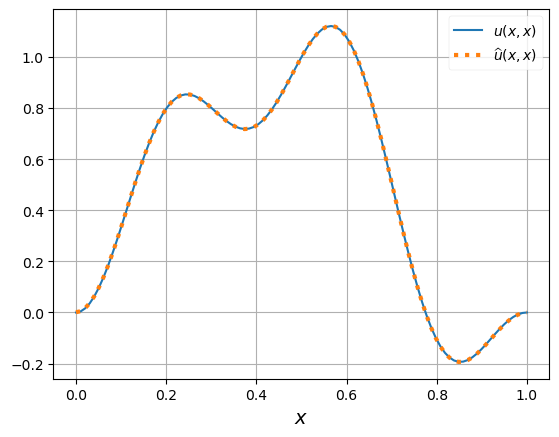

In [35]:
# Pred
fig, ax = plt.subplots(1, 1)

ax.grid(True)
ax.plot(np.diag(x), np.diag(ref), label='$u(x, x)$')
ax.plot(np.diag(x), np.diag(pred), ':', lw=3, label='$\widehat u(x, x)$')


#ax.set_title(r'(a).', pad=10, fontsize=12)
#ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

plt.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + 'pred_diag.pdf', bbox_inches ='tight')
plt.show()

In [36]:
epochs = range(n_epochs)

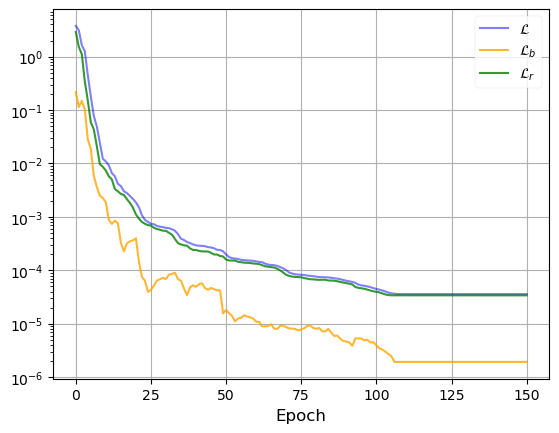

In [37]:
fig, axs = plt.subplots(1, 1)

axs.grid(True)
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)

axs.plot(epochs, losses['total'], "-", color='blue', lw=1.5, alpha=.5, label='$\mathcal{L}$')
axs.plot(epochs, losses['data'], "-", color='orange', lw=1.5, alpha=.8, label='$\mathcal{L}_b$')
axs.plot(epochs, losses['physics'], "-", color='green', lw=1.5, alpha=.8, label='$\mathcal{L}_r$')


axs.set_xticks(epochs[::25])
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + 'losses.pdf', bbox_inches ='tight')
plt.show()

In [38]:
marker_kw = dict(
    markevery=20, markersize=5, markerfacecolor="none"
)

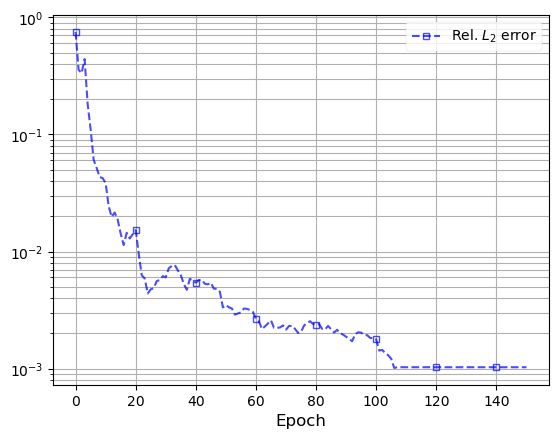

In [40]:
fig, axs = plt.subplots(1, 1)

axs.grid(True, which='both')
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)

axs.plot(epochs, losses['l2'], "--s", color='blue', alpha=.7, label='Rel. $L_2$ error', **marker_kw)
#axs.set_xticks(epochs)
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + 'l2_error.pdf', bbox_inches ='tight')
plt.show()

In [41]:
savesol = np.hstack([np.diag(x).reshape(-1, 1), np.diag(ref).reshape(-1, 1)])
np.savetxt(
    savedir+'galerkin',
    savesol
)

In [56]:
savesol = np.hstack([np.array(epochs).reshape(-1, 1), np.array(losses['l2']).reshape(-1, 1)])
np.savetxt(
    savefile+'l2_galerkin',
    savesol
)